# Form Coach — Notebook 01: Pose Inference

**Deliverable 1: Core Vision Tasks & Inference (25 pts)**

Loads an Ultralytics YOLO **pose estimation** model and runs real inference on video.
Pose is a task beyond plain detection, as the rubric requires.

Produces keypoint tensors, a joint-angle time series, and an annotated output video.

## 0. Colab setup

**Run this cell only in Google Colab.** Skip it if you are running locally.

In [1]:
!pip install -q ultralytics
!git clone -q https://github.com/alhmsiSWE/form-coach.git
%cd form-coach/notebooks

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 4.5 MB/s eta 0:00:00
/content/form-coach/notebooks


## 1. Setup

In [2]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)


In [3]:
import cv2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from IPython.display import Video, Image as IPImage

print("Imports OK")

Imports OK


## 2. Configuration

`SIDE` is the side of the body facing the camera. Far-side keypoints are occluded and
their confidence collapses, which makes the angles noisy. Cell 4 checks your choice.

In [4]:
# ---- EDIT THESE ----------------------------------------------------
VIDEO_PATH = "../videos/pushups.mp4"
SIDE       = "left"          # "left" or "right" - the side facing the camera
EXERCISE   = "pushup"        # "pushup" or "squat"
TARGET_FPS = 5               # frames per second to process
# --------------------------------------------------------------------

POSE_MODEL = "yolo26n-pose.pt"

# COCO-17 keypoint indices used by YOLO pose models
KEYPOINTS = {
    "nose": 0,
    "left_shoulder": 5,  "right_shoulder": 6,
    "left_elbow": 7,     "right_elbow": 8,
    "left_wrist": 9,     "right_wrist": 10,
    "left_hip": 11,      "right_hip": 12,
    "left_knee": 13,     "right_knee": 14,
    "left_ankle": 15,    "right_ankle": 16,
}

CHAIN = {
    "pushup": ["shoulder", "elbow", "wrist"],
    "squat":  ["hip", "knee", "ankle"],
}

joint_names = [f"{SIDE}_{j}" for j in CHAIN[EXERCISE]]
KPT_IDS = [KEYPOINTS[n] for n in joint_names]

print(f"Exercise : {EXERCISE}")
print(f"Side     : {SIDE}")
print(f"Tracking : {joint_names}")
print(f"kpts     : {KPT_IDS}   <-- notebook 02 needs these")

Exercise : pushup
Side     : left
Tracking : ['left_shoulder', 'left_elbow', 'left_wrist']
kpts     : [5, 7, 9]   <-- notebook 02 needs these


## 3. Open the video

In [5]:
print(f"Using: {VIDEO_PATH}")
assert os.path.exists(VIDEO_PATH), f"File not found: {VIDEO_PATH}"

cap = cv2.VideoCapture(VIDEO_PATH)
assert cap.isOpened(), f"Could not open {VIDEO_PATH}"
W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS = cap.get(cv2.CAP_PROP_FPS)
N   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

print(f"Resolution : {W} x {H}")
print(f"FPS        : {FPS}")
print(f"Frames     : {N}  (~{N/FPS:.1f} s)")

Using: ../videos/pushups.mp4
Resolution : 1080 x 1920
FPS        : 30.0
Frames     : 283  (~9.4 s)


## 4. Single-frame inference

Proves the model works and lets us inspect the raw keypoint tensor before processing
the whole clip.

People detected: 1
Keypoints tensor shape (persons, keypoints, xy): torch.Size([1, 17, 2])
Confidence tensor shape: torch.Size([1, 17])


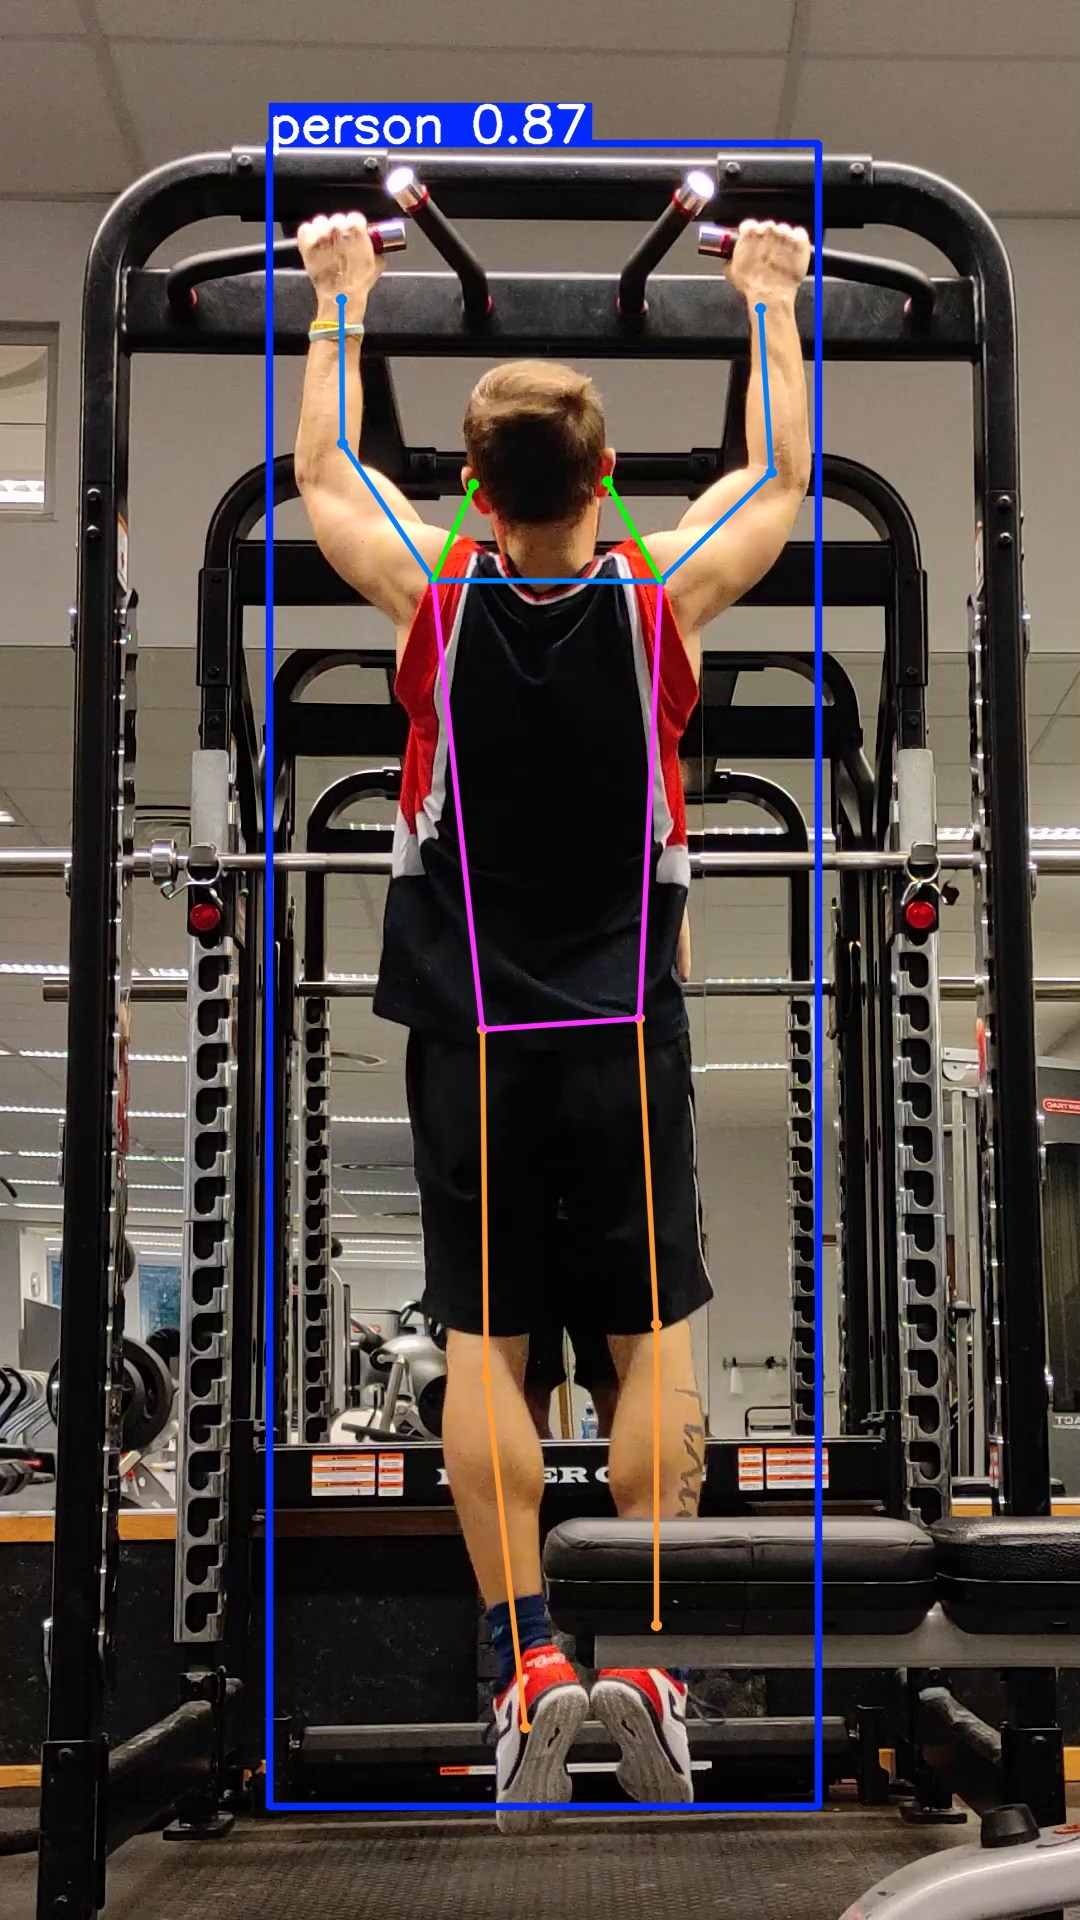

In [6]:
model = YOLO(POSE_MODEL)

cap = cv2.VideoCapture(VIDEO_PATH)
ok, first_frame = cap.read()
cap.release()
assert ok, "Could not read first frame"

results = model.predict(source=first_frame, verbose=False)
result = results[0]

print(f"People detected: {len(result.boxes)}")

if result.keypoints is not None and len(result.keypoints) > 0:
    print(f"Keypoints tensor shape (persons, keypoints, xy): {result.keypoints.xy.shape}")
    print(f"Confidence tensor shape: {result.keypoints.conf.shape}")
else:
    print("No keypoints found - the whole body must be visible in frame.")

annotated = result.plot()
cv2.imwrite("frame_pose.jpg", annotated)
IPImage(filename="frame_pose.jpg", width=700)

### Is SIDE correct?

In [7]:
if result.keypoints is not None and len(result.keypoints) > 0:
    conf = result.keypoints.conf[0].cpu().numpy()
    rows = []
    for joint in CHAIN[EXERCISE]:
        rows.append({
            "joint": joint,
            "left_conf":  round(float(conf[KEYPOINTS[f"left_{joint}"]]), 3),
            "right_conf": round(float(conf[KEYPOINTS[f"right_{joint}"]]), 3),
        })
    df_conf = pd.DataFrame(rows)
    print(df_conf.to_string(index=False))

    better = "left" if df_conf["left_conf"].mean() > df_conf["right_conf"].mean() else "right"
    print(f"\nHigher-confidence side: {better}  (SIDE is set to '{SIDE}')")
    if better != SIDE:
        print("--> Change SIDE in the config cell and Run All again.")

   joint  left_conf  right_conf
shoulder      0.998       0.998
   elbow      0.996       0.989
   wrist      0.992       0.964

Higher-confidence side: left  (SIDE is set to 'left')


## 5. Joint angle from keypoints

`AIGym` counts reps but does not expose the angle. Computing it ourselves gives a
measurable form signal: how deep each rep actually went.

In [8]:
def joint_angle(a, b, c):
    """Angle in degrees at point b, formed by points a-b-c."""
    a, b, c = np.asarray(a, float), np.asarray(b, float), np.asarray(c, float)
    ba, bc = a - b, c - b
    denom = np.linalg.norm(ba) * np.linalg.norm(bc)
    if denom < 1e-6:
        return np.nan
    cosine = np.clip(np.dot(ba, bc) / denom, -1.0, 1.0)
    return float(np.degrees(np.arccos(cosine)))


print("90 deg test:", round(joint_angle([0, 1], [0, 0], [1, 0]), 1))

90 deg test: 90.0


## 6. Process the full video

Frame sampling keeps this fast - we process `TARGET_FPS` frames per second instead of
all of them, the same pattern used in Lab 2.

In [9]:
MIN_CONF = 0.5   # ignore keypoints the model is unsure about

temp_out  = "pose_raw.mp4"
final_out = "01_pose_annotated.mp4"

cap = cv2.VideoCapture(VIDEO_PATH)
skip_rate = max(1, int(round(FPS / TARGET_FPS)))
writer = cv2.VideoWriter(temp_out, cv2.VideoWriter_fourcc(*'mp4v'), TARGET_FPS, (W, H))

records = []
frame_idx = 0
processed = 0

while cap.isOpened():
    ok, frame = cap.read()
    if not ok:
        break

    if frame_idx % skip_rate == 0:
        res = model.predict(source=frame, verbose=False)[0]
        annotated = res.plot()

        angle_val = np.nan
        if res.keypoints is not None and len(res.keypoints) > 0:
            xy   = res.keypoints.xy[0].cpu().numpy()
            conf = res.keypoints.conf[0].cpu().numpy()
            if all(conf[i] >= MIN_CONF for i in KPT_IDS):
                angle_val = joint_angle(*[xy[i] for i in KPT_IDS])

        if not np.isnan(angle_val):
            cv2.putText(annotated, f"{EXERCISE} angle: {angle_val:.0f} deg",
                        (30, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 255), 3)

        records.append({
            "frame": frame_idx,
            "time_s": round(frame_idx / FPS, 2),
            "angle": angle_val,
        })
        writer.write(annotated)
        processed += 1

    frame_idx += 1

cap.release()
writer.release()

df = pd.DataFrame(records)
valid = int(df["angle"].notna().sum())
print(f"Frames read      : {frame_idx}")
print(f"Frames processed : {processed}")
print(f"Angle captured   : {valid}/{len(df)} ({100*valid/max(len(df),1):.0f}%)")
if valid:
    print(f"Angle range      : {df['angle'].min():.0f} to {df['angle'].max():.0f} deg")

Frames read      : 283
Frames processed : 48
Angle captured   : 48/48 (100%)
Angle range      : 15 to 167 deg


In [10]:
if os.path.exists(temp_out):
    os.system(f"ffmpeg -i {temp_out} -vcodec libx264 -f mp4 {final_out} -y -loglevel quiet")

Video(final_out, embed=True, width=800)

## 7. The angle trace

Each dip is one rep. Shallow dips are reps with incomplete range of motion.

**Write down the printed thresholds** - notebook 02 needs them.

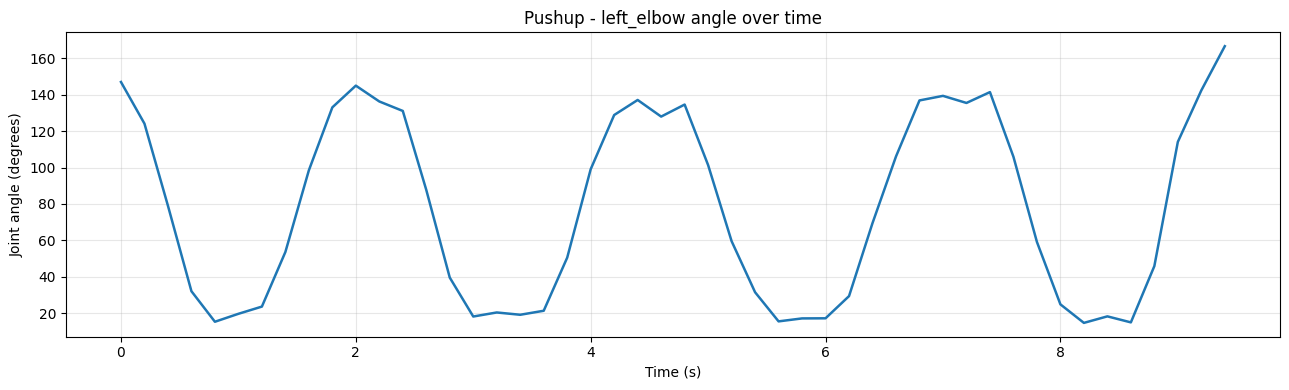

Suggested AIGym thresholds for notebook 02:
  down_angle = 25
  up_angle   = 157
Saved: 01_angle_data.csv


In [11]:
if df["angle"].notna().sum() > 0:
    plt.figure(figsize=(13, 4))
    plt.plot(df["time_s"], df["angle"], linewidth=1.8)
    plt.xlabel("Time (s)")
    plt.ylabel("Joint angle (degrees)")
    plt.title(f"{EXERCISE.capitalize()} - {joint_names[1]} angle over time")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("01_angle_trace.png", dpi=120)
    plt.show()

    print("Suggested AIGym thresholds for notebook 02:")
    print(f"  down_angle = {df['angle'].min() + 10:.0f}")
    print(f"  up_angle   = {df['angle'].max() - 10:.0f}")
else:
    print("No valid angles. Lower MIN_CONF, or use a clearer side-on video.")

df.to_csv("01_angle_data.csv", index=False)
print("Saved: 01_angle_data.csv")

## 8. Deliverable 1 evidence

| Artifact | File |
|---|---|
| Annotated pose video | `01_pose_annotated.mp4` |
| Single-frame proof | `frame_pose.jpg` |
| Angle trace plot | `01_angle_trace.png` |
| Raw angle data | `01_angle_data.csv` |

**Rubric mapping:** a YOLO model loaded and real inference run via the Python API on
video, results captured. Pose estimation is the task beyond plain detection, using
task-specific weights (`yolo26n-pose.pt`).

### Before closing
1. File -> Download -> Download .ipynb (**after** running, output intact)
2. Commit the notebook, the PNG and the CSV
3. Note the `down_angle` / `up_angle` values